# Pekino PM2.5 valandinė prognozė

**Tikslas:** prognozuoti kitos valandos PM2.5 koncentraciją $(\mathrm{PM2.5}(t+1))$ pagal UCI *Beijing PM2.5 Data* (2010–2014, valandiniai stebėjimai).

**Metodai:** Persistence / Last Value, Seasonal Mean, MLP, LSTM, XGBoost.

**Vertinimas:** chronologinis rolling-origin (walk-forward), be atsitiktinio `train_test_split`. Final test – **2014 m.** Hiperparametrai parenkami **tik 2013 m. validacijoje**.

**Pavojingas lygis:** $(\tau = 150\,\mu g/m^3)$ (Kinijos AQI „heavily polluted“ riba valandinei analizei). Recall: $(\mathrm{Recall} = TP / (TP + FN))$, kur teigiama klasė yra $(\mathrm{PM2.5}(t+1) \ge \tau)$.


## 1. Nustatymai, sėklos ir bibliotekos


In [2]:
from __future__ import annotations

import json
import math
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
DANGER_THRESHOLD = 150.0  # µg/m³, ta pati visiems metodams
SEQ_LEN = 24
BATCH_SIZE = 512
LSTM_EPOCHS_HP = 25
LSTM_EPOCHS_FINAL = 40

ROOT = Path(".").resolve()
DATA_PATH = ROOT / "data" / "PRSA_data_2010.1.1-2014.12.31.csv"
FIG_DIR = ROOT / "figures"
RES_DIR = ROOT / "results"
FIG_DIR.mkdir(exist_ok=True)
RES_DIR.mkdir(exist_ok=True)


def set_seeds(seed: int = RANDOM_SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.use_deterministic_algorithms(False)


set_seeds()
torch.set_num_threads(4)
DEVICE = torch.device("cpu")
print("Python / torch:", torch.__version__, "device:", DEVICE)
print("DATA_PATH exists:", DATA_PATH.exists())


Python / torch: 2.14.0+cpu device: cpu
DATA_PATH exists: True


## 2. Metrikos ir pavojingo lygio apibrėžimas

- **MAE** = $(\frac{1}{n}\sum_i |y_i - \hat y_i|)$
- **RMSE** = $(\sqrt{\frac{1}{n}\sum_i (y_i - \hat y_i)^2})$
- **Dangerous Level Recall**: $(y_i \ge 150)$ yra pavojingas pikas; prognozė teigiama, jei $(\hat y_i \ge 150)$.

$$
\mathrm{Recall} = \frac{TP}{TP+FN}
$$

Jei $(TP+FN=0)$ (testo lange nėra pavojingų valandų), Recall žymimas kaip NaN.


In [3]:
def regression_metrics(y_true, y_pred, threshold: float = DANGER_THRESHOLD) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(math.sqrt(mean_squared_error(y_true, y_pred)))
    actual_pos = y_true >= threshold
    pred_pos = y_pred >= threshold
    tp = int(np.sum(actual_pos & pred_pos))
    fn = int(np.sum(actual_pos & ~pred_pos))
    fp = int(np.sum(~actual_pos & pred_pos))
    denom = tp + fn
    recall = float(tp / denom) if denom > 0 else float("nan")
    return {
        "MAE": mae,
        "RMSE": rmse,
        "Dangerous_Recall": recall,
        "TP": tp,
        "FN": fn,
        "FP": fp,
        "n": int(len(y_true)),
        "n_danger": int(actual_pos.sum()),
    }


def metrics_row(name: str, y_true, y_pred) -> dict:
    row = {"method": name}
    row.update(regression_metrics(y_true, y_pred))
    return row


## 3. Duomenų įkėlimas, datetime ir trūkstamos reikšmės

Naudojamas failas `data/PRSA_data_2010.1.1-2014.12.31.csv`. 
PM2.5 ir meteorologiniuose duomenyse yra trūkstamų reikšmių.
Istoriniams požymiams naudojama paskutinė žinoma reikšmė (`forward fill`).

Svarbu, kad target reikšmės nebūtų užpildomos taip, kad į mokymo ar
vertinimo procesą patektų ateities informacija.

Po trūkstamų reikšmių tvarkymo pašalinamos eilutės, kurioms negalima
sudaryti reikalingų istorinių požymių.


In [4]:
raw = pd.read_csv(DATA_PATH, na_values=["NA", "NaN", ""])
print("Eilučių:", len(raw), "stulpelių:", list(raw.columns))
print(raw.head(3))

raw["datetime"] = pd.to_datetime(raw[["year", "month", "day", "hour"]])
raw = raw.sort_values("datetime").drop_duplicates("datetime")
raw = raw.set_index("datetime")

print("\nTrūkstamos reikšmės prieš apdorojimą:")
print(raw.isna().sum())
print("PM2.5 NA dalis: {:.2f}%".format(100 * raw["pm2.5"].isna().mean()))

pm_na_before = int(raw["pm2.5"].isna().sum())

# Operacinis užpildymas be ateities: tik ffill (pirmos NA eilutės lieka NA ir vėliau išmetamos)
df = raw.copy()
df["pm2.5"] = df["pm2.5"].ffill()
for col in ["DEWP", "TEMP", "PRES", "Iws", "Is", "Ir"]:
    df[col] = df[col].ffill()
df["cbwd"] = df["cbwd"].ffill()

display("\nPo ffill PM2.5 NA:", int(df["pm2.5"].isna().sum()), "(prieš:", pm_na_before, ")")
print("Laikotarpis:", df.index.min(), "→", df.index.max())


Eilučių: 43824 stulpelių: ['No', 'year', 'month', 'day', 'hour', 'pm2.5', 'DEWP', 'TEMP', 'PRES', 'cbwd', 'Iws', 'Is', 'Ir']
   No  year  month  day  hour  pm2.5  DEWP  TEMP    PRES cbwd   Iws  Is  Ir
0   1  2010      1    1     0    NaN   -21 -11.0  1021.0   NW  1.79   0   0
1   2  2010      1    1     1    NaN   -21 -12.0  1020.0   NW  4.92   0   0
2   3  2010      1    1     2    NaN   -21 -11.0  1019.0   NW  6.71   0   0

Trūkstamos reikšmės prieš apdorojimą:
No          0
year        0
month       0
day         0
hour        0
pm2.5    2067
DEWP        0
TEMP        0
PRES        0
cbwd        0
Iws         0
Is          0
Ir          0
dtype: int64
PM2.5 NA dalis: 4.72%


'\nPo ffill PM2.5 NA:'

24

'(prieš:'

2067

')'

Laikotarpis: 2010-01-01 00:00:00 → 2014-12-31 23:00:00


## 4. Target, požymiai, lag ir apsauga nuo data leakage

- Target: `target = PM2.5(t+1)` = `pm2.5.shift(-1)` (poslinkis į **ateitį** tik etiketėje).
- Požymiai laiko momentu \(t\): dabartinis PM2.5, meteorologija, cikliniai laiko kodai, lagai \(\{1,2,3,24,168\}\).
- Lagai skaičiuojami `shift(+k)` – tik praeitis.
- Seasonal mean later naudoja `shift(1).expanding()` grupėje pagal valandą.
- Standartizacija ir hiperparametrai – tik pagal mokymo / validacijos langą, niekada pagal 2014 testą.


In [5]:
df["target"] = df["pm2.5"].shift(-1)
df["hour"] = df.index.hour
df["month"] = df.index.month
df["dow"] = df.index.dayofweek
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
df["dow_sin"] = np.sin(2 * np.pi * df["dow"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dow"] / 7)

LAGS = (1, 2, 3, 24, 168)
for lag in LAGS:
    df[f"pm_lag{lag}"] = df["pm2.5"].shift(lag)

cbwd_dummies = pd.get_dummies(df["cbwd"], prefix="cbwd", dtype=float)
df = pd.concat([df, cbwd_dummies], axis=1)

METEO = ["DEWP", "TEMP", "PRES", "Iws", "Is", "Ir"]
TIME_FEATS = ["hour_sin", "hour_cos", "month_sin", "month_cos", "dow_sin", "dow_cos"]
LAG_FEATS = [f"pm_lag{lag}" for lag in LAGS]
WIND_FEATS = list(cbwd_dummies.columns)
FEATURE_COLS = ["pm2.5"] + METEO + TIME_FEATS + LAG_FEATS + WIND_FEATS

# Seasonal mean be nuotėkio: tos pačios valandos vidurkis iš GRIEŽTAI ankstesnių stebėjimų
df["seasonal_mean_expanding"] = (
    df.groupby("hour")["pm2.5"].transform(lambda s: s.shift(1).expanding(min_periods=24).mean())
)

needed = FEATURE_COLS + ["target", "seasonal_mean_expanding"]
df_model = df.dropna(subset=needed).copy()
print("Po NA išmetimo (lag 168 + target + ffill pradžia):", len(df_model), "eilučių")
print("Požymiai:", FEATURE_COLS)


def split_chrono(frame: pd.DataFrame):
    train = frame.loc[: "2012-12-31 23:00:00"]
    val = frame.loc["2013-01-01":"2013-12-31"]
    test = frame.loc["2014-01-01":]
    return train, val, test


train_df, val_df, test_df = split_chrono(df_model)
print("Train:", train_df.index.min(), "→", train_df.index.max(), "n=", len(train_df))
print("Val:  ", val_df.index.min(), "→", val_df.index.max(), "n=", len(val_df))
print("Test: ", test_df.index.min(), "→", test_df.index.max(), "n=", len(test_df))
assert train_df.index.max() < val_df.index.min()
assert val_df.index.max() < test_df.index.min()
display("Chronologija OK: train < val < test")


Po NA išmetimo (lag 168 + target + ffill pradžia): 43223 eilučių
Požymiai: ['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'pm_lag1', 'pm_lag2', 'pm_lag3', 'pm_lag24', 'pm_lag168', 'cbwd_NE', 'cbwd_NW', 'cbwd_SE', 'cbwd_cv']
Train: 2010-01-26 00:00:00 → 2012-12-31 23:00:00 n= 25704
Val:   2013-01-01 00:00:00 → 2013-12-31 23:00:00 n= 8760
Test:  2014-01-01 00:00:00 → 2014-12-31 22:00:00 n= 8759


'Chronologija OK: train < val < test'

## 5. Rolling-origin protokolas

Final test (2014) skaidomas į keturis ketvirčius. Kiekviename origino taške modelis mokomas **tik iš duomenų iki origin** (įskaitant ankstesnius test ketvirčius – tai ir yra expanding rolling-origin). Hiperparametrai vis tiek parinkti tik 2013 validacijoje, niekada 2014.

Persistence ir Seasonal Mean skaičiuojami kiekvienai valandai be mokymo, bet Seasonal Mean vis tiek naudoja tik praeitį.


In [6]:
ORIGINS = [
    pd.Timestamp("2014-01-01"),
    pd.Timestamp("2014-04-01"),
    pd.Timestamp("2014-07-01"),
    pd.Timestamp("2014-10-01"),
]
ORIGIN_ENDS = ORIGINS[1:] + [df_model.index.max() + pd.Timedelta(hours=1)]


def window_slice(frame: pd.DataFrame, start, end) -> pd.DataFrame:
    return frame[(frame.index >= start) & (frame.index < end)]


def fit_scaler(train_part: pd.DataFrame) -> StandardScaler:
    scaler = StandardScaler()
    scaler.fit(train_part[FEATURE_COLS].to_numpy(dtype=float))
    return scaler


## 6. Baseline

- Persistence: $(\hat y(t+1) = \mathrm{PM2.5}(t))$.
    Persistence prognozuoja, kad kitos valandos PM2.5 reikšmė bus lygi paskutinei žinomai reikšmei.
    Tai paprastas atskaitos metodas, paremtas prielaida, kad per vieną valandą PM2.5 koncentracija dažnai stipriai nepasikeičia.
- Seasonal Mean: tos pačios paros valandos istorinis vidurkis iš visų ankstesnių stebėjimų (`seasonal_mean_expanding`).
    Svarbu, kad vidurkis skaičiuojamas tik iš iki prognozavimo momento buvusių duomenų. Tam naudojamas ankstesnių reikšmių kaupimas, todėl būsima informacija nėra naudojama prognozei.

Šie baseline metodai leidžia patikrinti, ar sudėtingesni modeliai suteikia papildomos naudos, palyginti su labai paprastomis prognozėmis.

In [7]:
base_rows = []
pred_store = {}

y_test = test_df["target"].to_numpy(dtype=float)
pred_persist = test_df["pm2.5"].to_numpy(dtype=float)
pred_seasonal = test_df["seasonal_mean_expanding"].to_numpy(dtype=float)

pred_store["Persistence"] = pred_persist
pred_store["Seasonal Mean"] = pred_seasonal
base_rows.append(metrics_row("Persistence", y_test, pred_persist))
base_rows.append(metrics_row("Seasonal Mean", y_test, pred_seasonal))
display(pd.DataFrame(base_rows).round(4))


,method,MAE,RMSE,Dangerous_Recall,TP,FN,FP,n,n_danger
0,Persistence,11.8251,22.0123,0.9027,1614,174,174,8759,1788
1,Seasonal Mean,69.0366,93.3809,0.0000,0,1788,0,8759,1788


## 7. XGBoost – teorija ir kodas

Gradientinis boosting stato adityvų modelį:

$$
F_m(x) = F_{m-1}(x) + \eta h_m(x),
$$

kur $h_m(x)$ yra naujas medis, aproksimuojantis nuostolio gradientą (MSE atveju – liekanas), o $\eta$ – `learning_rate`. `n_estimators` = $M$ (medžių / boosting žingsnių skaičius).

Žemiau `learning_rate` ir `n_estimators` yra **tiesioginiai** $\eta$ ir $M$ atitikmenys kode.

Mokymo metu naudojama kvadratinės paklaidos funkcija:

$$
L(y,\hat{y}) = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2,
$$

kur $y_i$ yra tikroji reikšmė, o $\hat{y}_i$ – modelio prognozė. Kode ši nuostolio funkcija nurodoma naudojant `objective="reg:squarederror"`.

Taigi teorinė XGBoost formulė ir nuostolio funkcija tiesiogiai siejamos su modelio parametrais ir mokymo nustatymais kode.

In [8]:
DANGER_WEIGHT = 4.0

def make_sample_weight(y) -> np.ndarray:
    y = np.asarray(y, dtype=float)
    return np.where(y >= DANGER_THRESHOLD, DANGER_WEIGHT, 1.0)

def eval_xgb_on_val(params: dict) -> float:
    model = XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_SEED,
        n_jobs=4,
        tree_method="hist",
        **params,
    )
    w = make_sample_weight(train_df["target"])
    model.fit(train_df[FEATURE_COLS], train_df["target"], sample_weight=w)
    pred = model.predict(val_df[FEATURE_COLS])
    return float(mean_absolute_error(val_df["target"], pred))


xgb_grid = [
    {"n_estimators": 80,  "max_depth": 3, "learning_rate": 0.08, "subsample": 0.8, "colsample_bytree": 0.8},
    {"n_estimators": 150, "max_depth": 4, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8},
    {"n_estimators": 120, "max_depth": 5, "learning_rate": 0.08, "subsample": 0.9, "colsample_bytree": 0.9},
    {"n_estimators": 300, "max_depth": 4, "learning_rate": 0.03, "subsample": 0.8, "colsample_bytree": 0.8, "min_child_weight": 3},
    {"n_estimators": 200, "max_depth": 6, "learning_rate": 0.04, "subsample": 0.7, "colsample_bytree": 0.7, "reg_lambda": 1.5},
]

xgb_val_scores = []
for p in xgb_grid:
    mae = eval_xgb_on_val(p)
    xgb_val_scores.append((mae, p))
    print("VAL MAE", round(mae, 4), p)

best_xgb_mae, best_xgb_params = min(xgb_val_scores, key=lambda t: t[0])
print("\nGeriausi XGBoost HP pagal 2013 VAL MAE:", best_xgb_params, "MAE=", round(best_xgb_mae, 4))
print("n_estimators=M, learning_rate=eta")
print("M =", best_xgb_params["n_estimators"], " eta =", best_xgb_params["learning_rate"])


VAL MAE 13.7868 {'n_estimators': 80, 'max_depth': 3, 'learning_rate': 0.08, 'subsample': 0.8, 'colsample_bytree': 0.8}
VAL MAE 13.6596 {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}
VAL MAE 13.5466 {'n_estimators': 120, 'max_depth': 5, 'learning_rate': 0.08, 'subsample': 0.9, 'colsample_bytree': 0.9}
VAL MAE 13.6108 {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 3}
VAL MAE 13.5341 {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.04, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_lambda': 1.5}

Geriausi XGBoost HP pagal 2013 VAL MAE: {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.04, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_lambda': 1.5} MAE= 13.5341
n_estimators=M, learning_rate=eta
M = 200  eta = 0.04


In [9]:
def rolling_xgb_predict() -> np.ndarray:
    preds = np.full(len(test_df), np.nan)
    for origin, end in zip(ORIGINS, ORIGIN_ENDS):
        hist = df_model[df_model.index < origin]
        fold = window_slice(test_df, origin, end)
        if len(hist) == 0 or len(fold) == 0:
            continue
        model = XGBRegressor(
            objective="reg:squarederror",
            random_state=RANDOM_SEED,
            n_jobs=4,
            tree_method="hist",
            **best_xgb_params,
        )
        w = make_sample_weight(hist["target"])
        model.fit(hist[FEATURE_COLS], hist["target"], sample_weight=w)
        preds[test_df.index.get_indexer(fold.index)] = model.predict(fold[FEATURE_COLS])
        print("XGBoost origin", origin.date(), "train_n=", len(hist), "pred_n=", len(fold))
    return preds


pred_xgb = rolling_xgb_predict()
pred_store["XGBoost"] = pred_xgb
print(metrics_row("XGBoost", y_test, pred_xgb))


XGBoost origin 2014-01-01 train_n= 34464 pred_n= 2160
XGBoost origin 2014-04-01 train_n= 36624 pred_n= 2184
XGBoost origin 2014-07-01 train_n= 38808 pred_n= 2208
XGBoost origin 2014-10-01 train_n= 41016 pred_n= 2207
{'method': 'XGBoost', 'MAE': 11.907180027107572, 'RMSE': 21.241179643657826, 'Dangerous_Recall': 0.9507829977628636, 'TP': 1700, 'FN': 88, 'FP': 308, 'n': 8759, 'n_danger': 1788}


## 8. MLP

Daugiasluoksnis perceptronas (`sklearn.MLPRegressor`). `early_stopping` išjungtas, kad nebūtų vidinio atsitiktinio validacijos skaidinio. Hiperparametrai – tik pagal 2013 VAL MAE.


In [10]:
mlp_grid = [
    {"hidden_layer_sizes": (32,), "alpha": 1e-4},
    {"hidden_layer_sizes": (64, 32), "alpha": 1e-4},
    {"hidden_layer_sizes": (64, 32), "alpha": 1e-3},
]


def make_mlp(hp: dict) -> MLPRegressor:
    return MLPRegressor(
        activation="relu",
        solver="adam",
        max_iter=40,
        shuffle=False,
        random_state=RANDOM_SEED,
        early_stopping=False,
        learning_rate_init=0.001,
        **hp,
    )


scaler_hp = fit_scaler(train_df)
Xtr = scaler_hp.transform(train_df[FEATURE_COLS])
Xva = scaler_hp.transform(val_df[FEATURE_COLS])

mlp_val_scores = []
for hp in mlp_grid:
    set_seeds()
    m = make_mlp(hp)
    m.fit(Xtr, train_df["target"].to_numpy(dtype=float))
    mae = float(mean_absolute_error(val_df["target"], m.predict(Xva)))
    mlp_val_scores.append((mae, hp))
    print("VAL MAE", round(mae, 4), hp)

best_mlp_mae, best_mlp_hp = min(mlp_val_scores, key=lambda t: t[0])
print("Geriausias MLP HP:", best_mlp_hp, "VAL MAE", round(best_mlp_mae, 4))


VAL MAE 14.9876 {'hidden_layer_sizes': (32,), 'alpha': 0.0001}
VAL MAE 14.418 {'hidden_layer_sizes': (64, 32), 'alpha': 0.0001}
VAL MAE 14.4399 {'hidden_layer_sizes': (64, 32), 'alpha': 0.001}
Geriausias MLP HP: {'hidden_layer_sizes': (64, 32), 'alpha': 0.0001} VAL MAE 14.418


In [11]:
def rolling_mlp_predict() -> np.ndarray:
    preds = np.full(len(test_df), np.nan)
    for origin, end in zip(ORIGINS, ORIGIN_ENDS):
        hist = df_model[df_model.index < origin]
        fold = window_slice(test_df, origin, end)
        scaler = fit_scaler(hist)
        set_seeds()
        model = make_mlp(best_mlp_hp)
        model.fit(scaler.transform(hist[FEATURE_COLS]), hist["target"].to_numpy(dtype=float))
        preds[test_df.index.get_indexer(fold.index)] = model.predict(scaler.transform(fold[FEATURE_COLS]))
        print("MLP origin", origin.date(), "train_n=", len(hist), "pred_n=", len(fold))
    return preds


pred_mlp = rolling_mlp_predict()
pred_store["MLP"] = pred_mlp
print(metrics_row("MLP", y_test, pred_mlp))


MLP origin 2014-01-01 train_n= 34464 pred_n= 2160
MLP origin 2014-04-01 train_n= 36624 pred_n= 2184
MLP origin 2014-07-01 train_n= 38808 pred_n= 2208
MLP origin 2014-10-01 train_n= 41016 pred_n= 2207
{'method': 'MLP', 'MAE': 12.636384535933306, 'RMSE': 21.608050573092957, 'Dangerous_Recall': 0.9149888143176734, 'TP': 1636, 'FN': 152, 'FP': 226, 'n': 8759, 'n_danger': 1788}


## 9. LSTM

Vieno sluoksnio LSTM ima paskutinių 24 valandų požymių seką ir prognozuoja $(\mathrm{PM2.5}(t+1))$. Sekos sudaromos taip, kad paskutinis žingsnis būtų laikas $(t)$ (be būsimų valandų). Skalė ir svoriai mokomi tik iš duomenų iki origin.
LSTM mokomas atskirai kiekviename `rolling-origin` etape. Duomenų standartizavimo (`scaling`) parametrai ir modelio svoriai apskaičiuojami tik iš duomenų iki konkretaus `origin`. Testavimo duomenys naudojami tik galutiniam modelio įvertinimui.

Taip išvengiama `data leakage` ir užtikrinama, kad modelis prognozuodamas ateitį naudotų tik tuo metu prieinamą informaciją.

In [12]:
class LSTMForecaster(nn.Module):
    def __init__(self, n_features: int, hidden: int = 32):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, num_layers=1, batch_first=True)
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)


def make_sequences(X: np.ndarray, y: np.ndarray, seq_len: int, start: int, end: int):
    first = max(start, seq_len - 1)
    if end - first <= 0:
        return np.empty((0, seq_len, X.shape[1])), np.empty((0,))
    n = end - first
    seq = np.stack([X[i - seq_len + 1 : i + 1] for i in range(first, end)])
    return seq, y[first:end]


def train_lstm(X_hist, y_hist, hidden: int, epochs: int, lr: float = 1e-3):
    set_seeds()
    y_mean = float(np.mean(y_hist))
    y_std = float(np.std(y_hist)) or 1.0
    y_hist_scaled = (y_hist - y_mean) / y_std  # <- KEY FIX: target irgi skaluojamas

    model = LSTMForecaster(X_hist.shape[1], hidden=hidden).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    xs, ys = make_sequences(X_hist, y_hist_scaled, SEQ_LEN, 0, len(X_hist))
    ds = TensorDataset(
        torch.tensor(xs, dtype=torch.float32),
        torch.tensor(ys, dtype=torch.float32),
    )
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)
    model.train()
    for epoch in range(epochs):
        total_loss, n_batches = 0.0, 0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
            total_loss += loss.item()
            n_batches += 1
        print(f"    epoch {epoch+1}/{epochs}  scaled_MSE={total_loss/n_batches:.4f}")
    return model, y_mean, y_std


def lstm_predict(model, X_all, start, end, y_mean: float, y_std: float) -> np.ndarray:
    xs, _ = make_sequences(X_all, np.zeros(len(X_all)), SEQ_LEN, start, end)
    if len(xs) == 0:
        return np.array([])
    model.eval()
    with torch.no_grad():
        pred_scaled = model(torch.tensor(xs, dtype=torch.float32).to(DEVICE)).cpu().numpy()
    return pred_scaled * y_std + y_mean


# HP paieška tik VAL (mokoma ant train, seka gali siekti train pabaigą)
lstm_hidden_grid = [16, 32]
scaler_lstm_hp = fit_scaler(train_df)
full_for_hp = pd.concat([train_df, val_df])
X_hp = scaler_lstm_hp.transform(full_for_hp[FEATURE_COLS])
y_hp = full_for_hp["target"].to_numpy(dtype=float)
train_end = len(train_df)
val_end = len(full_for_hp)

lstm_val_scores = []
for h in lstm_hidden_grid:
    print(f"HP kandidatas hidden={h}")
    model, y_mean_hp, y_std_hp = train_lstm(X_hp[:train_end], y_hp[:train_end], hidden=h, epochs=LSTM_EPOCHS_HP)
    pred = lstm_predict(model, X_hp, train_end, val_end, y_mean_hp, y_std_hp)
    yv = y_hp[max(train_end, SEQ_LEN - 1) : val_end]
    mae = float(mean_absolute_error(yv, pred))
    lstm_val_scores.append((mae, h))
    print("LSTM VAL MAE", round(mae, 4), "hidden", h)

best_lstm_mae, best_lstm_hidden = min(lstm_val_scores, key=lambda t: t[0])
print("Geriausias LSTM hidden:", best_lstm_hidden, "VAL MAE", round(best_lstm_mae, 4))


HP kandidatas hidden=16
    epoch 1/25  scaled_MSE=0.8449
    epoch 2/25  scaled_MSE=0.5274
    epoch 3/25  scaled_MSE=0.3386
    epoch 4/25  scaled_MSE=0.2688
    epoch 5/25  scaled_MSE=0.2253
    epoch 6/25  scaled_MSE=0.1930
    epoch 7/25  scaled_MSE=0.1676
    epoch 8/25  scaled_MSE=0.1476
    epoch 9/25  scaled_MSE=0.1321
    epoch 10/25  scaled_MSE=0.1203
    epoch 11/25  scaled_MSE=0.1110
    epoch 12/25  scaled_MSE=0.1036
    epoch 13/25  scaled_MSE=0.0975
    epoch 14/25  scaled_MSE=0.0923
    epoch 15/25  scaled_MSE=0.0880
    epoch 16/25  scaled_MSE=0.0843
    epoch 17/25  scaled_MSE=0.0811
    epoch 18/25  scaled_MSE=0.0785
    epoch 19/25  scaled_MSE=0.0763
    epoch 20/25  scaled_MSE=0.0745
    epoch 21/25  scaled_MSE=0.0731
    epoch 22/25  scaled_MSE=0.0719
    epoch 23/25  scaled_MSE=0.0709
    epoch 24/25  scaled_MSE=0.0702
    epoch 25/25  scaled_MSE=0.0695
LSTM VAL MAE 13.6319 hidden 16
HP kandidatas hidden=32
    epoch 1/25  scaled_MSE=0.6990
    epoch 2/25  scale

In [13]:
def rolling_lstm_predict() -> np.ndarray:
    preds = np.full(len(test_df), np.nan)
    full = df_model
    X_raw = full[FEATURE_COLS].to_numpy(dtype=float)
    y_raw = full["target"].to_numpy(dtype=float)
    idx = full.index
    test_pos = {t: i for i, t in enumerate(test_df.index)}
    for origin, end in zip(ORIGINS, ORIGIN_ENDS):
        hist_mask = idx < origin
        hist_end = int(hist_mask.sum())
        fold_mask = (idx >= origin) & (idx < end)
        fold_idx = np.where(fold_mask)[0]
        if hist_end < SEQ_LEN or len(fold_idx) == 0:
            continue
        scaler = StandardScaler().fit(X_raw[:hist_end])
        X_sc = scaler.transform(X_raw)
        model, y_mean_f, y_std_f = train_lstm(
            X_sc[:hist_end], y_raw[:hist_end], hidden=best_lstm_hidden, epochs=LSTM_EPOCHS_FINAL
        )
        start_pred = int(fold_idx[0])
        end_pred = int(fold_idx[-1]) + 1
        pred = lstm_predict(model, X_sc, start_pred, end_pred, y_mean_f, y_std_f)
        first = max(start_pred, SEQ_LEN - 1)
        pred_index = full.index[first:end_pred]
        for ts, p in zip(pred_index, pred):
            if ts in test_pos:
                preds[test_pos[ts]] = p
        print("LSTM origin", origin.date(), "hist_n=", hist_end, "pred_n=", len(pred))
    return preds


pred_lstm = rolling_lstm_predict()
pred_store["LSTM"] = pred_lstm
print(metrics_row("LSTM", y_test, pred_lstm))


    epoch 1/40  scaled_MSE=0.6047
    epoch 2/40  scaled_MSE=0.2552
    epoch 3/40  scaled_MSE=0.1876
    epoch 4/40  scaled_MSE=0.1504
    epoch 5/40  scaled_MSE=0.1250
    epoch 6/40  scaled_MSE=0.1071
    epoch 7/40  scaled_MSE=0.0942
    epoch 8/40  scaled_MSE=0.0846
    epoch 9/40  scaled_MSE=0.0774
    epoch 10/40  scaled_MSE=0.0721
    epoch 11/40  scaled_MSE=0.0680
    epoch 12/40  scaled_MSE=0.0672
    epoch 13/40  scaled_MSE=0.0674
    epoch 14/40  scaled_MSE=0.0661
    epoch 15/40  scaled_MSE=0.0644
    epoch 16/40  scaled_MSE=0.0627
    epoch 17/40  scaled_MSE=0.0617
    epoch 18/40  scaled_MSE=0.0619
    epoch 19/40  scaled_MSE=0.0618
    epoch 20/40  scaled_MSE=0.0609
    epoch 21/40  scaled_MSE=0.0615
    epoch 22/40  scaled_MSE=0.0618
    epoch 23/40  scaled_MSE=0.0604
    epoch 24/40  scaled_MSE=0.0610
    epoch 25/40  scaled_MSE=0.0611
    epoch 26/40  scaled_MSE=0.0594
    epoch 27/40  scaled_MSE=0.0597
    epoch 28/40  scaled_MSE=0.0598
    epoch 29/40  scaled_MSE=0

## 10. Bendri final test rezultatai (2014, rolling-origin)


In [14]:
order = ["Persistence", "Seasonal Mean", "MLP", "LSTM", "XGBoost"]
rows = [metrics_row(name, y_test, pred_store[name]) for name in order]
results_table = pd.DataFrame(rows).set_index("method")
display_cols = ["MAE", "RMSE", "Dangerous_Recall", "TP", "FN", "n_danger", "n"]
print("Riba tau =", DANGER_THRESHOLD, "µg/m³")
display(results_table[display_cols].round(4))
results_table.to_csv(RES_DIR / "final_test_metrics.csv")


Riba tau = 150.0 µg/m³


,MAE,RMSE,Dangerous_Recall,TP,FN,n_danger,n
method,,,,,,,
Persistence,11.8251,22.0123,0.9027,1614,174,1788,8759
Seasonal Mean,69.0366,93.3809,0.0000,0,1788,1788,8759
MLP,12.6364,21.6081,0.9150,1636,152,1788,8759
LSTM,11.8491,20.8000,0.9066,1621,167,1788,8759
XGBoost,11.9072,21.2412,0.9508,1700,88,1788,8759


## 11. Abliacija / požymių jautrumas (XGBoost)

Tos pačios 2013 m. parinktos HP, rolling-origin 2014. Lyginami požymių rinkiniai: visi, be meteorologijos, be lagų, be laiko požymių.


In [15]:
ABLATION = {
    "full": FEATURE_COLS,
    "no_meteo": [c for c in FEATURE_COLS if c not in METEO],
    "no_lags": [c for c in FEATURE_COLS if c not in LAG_FEATS],
    "no_time": [c for c in FEATURE_COLS if c not in TIME_FEATS],
}


def rolling_xgb_on_cols(cols: list[str]) -> np.ndarray:
    preds = np.full(len(test_df), np.nan)
    for origin, end in zip(ORIGINS, ORIGIN_ENDS):
        hist = df_model[df_model.index < origin]
        fold = window_slice(test_df, origin, end)
        model = XGBRegressor(
            objective="reg:squarederror",
            random_state=RANDOM_SEED,
            n_jobs=4,
            tree_method="hist",
            **best_xgb_params,
        )
        model.fit(hist[cols], hist["target"])
        preds[test_df.index.get_indexer(fold.index)] = model.predict(fold[cols])
    return preds


ablation_rows = []
ablation_preds = {}
for name, cols in ABLATION.items():
    p = rolling_xgb_on_cols(cols)
    ablation_preds[name] = p
    row = metrics_row(f"XGB_{name}", y_test, p)
    ablation_rows.append(row)
    print(name, "n_features=", len(cols), {k: row[k] for k in ["MAE", "RMSE", "Dangerous_Recall"]})

ablation_table = pd.DataFrame(ablation_rows).set_index("method")
ablation_table.to_csv(RES_DIR / "ablation_xgb.csv")
display(ablation_table[display_cols].round(4))


full n_features= 22 {'MAE': 11.544631440449773, 'RMSE': 21.015954469586877, 'Dangerous_Recall': 0.9038031319910514}
no_meteo n_features= 16 {'MAE': 11.628474354975326, 'RMSE': 21.43511988586199, 'Dangerous_Recall': 0.8987695749440716}
no_lags n_features= 17 {'MAE': 12.660395175366377, 'RMSE': 22.298736263585507, 'Dangerous_Recall': 0.8870246085011185}
no_time n_features= 16 {'MAE': 11.650078868550217, 'RMSE': 21.231427207388325, 'Dangerous_Recall': 0.8976510067114094}


,MAE,RMSE,Dangerous_Recall,TP,FN,n_danger,n
method,,,,,,,
XGB_full,11.5446,21.0160,0.9038,1616,172,1788,8759
XGB_no_meteo,11.6285,21.4351,0.8988,1607,181,1788,8759
XGB_no_lags,12.6604,22.2987,0.8870,1586,202,1788,8759
XGB_no_time,11.6501,21.2314,0.8977,1605,183,1788,8759


## 12. Atsparumo eksperimentas

Papildomai atsitiktinai paslepiama 15 % **stebėtų** PM2.5 reikšmių (sėkla 42), tada tas pats `ffill`. Perkuriame lagus ir seasonal mean. Lyginame Persistence ir XGBoost su baziniu scenarijumi.


In [16]:
set_seeds(RANDOM_SEED)
raw_rob = raw.copy()
observed = raw_rob["pm2.5"].notna().to_numpy()
idx_obs = np.where(observed)[0]
hide_n = int(0.15 * len(idx_obs))
hide = np.random.choice(idx_obs, size=hide_n, replace=False)
raw_rob.iloc[hide, raw_rob.columns.get_loc("pm2.5")] = np.nan

df_r = raw_rob.copy()
df_r["pm2.5"] = df_r["pm2.5"].ffill()
for col in ["DEWP", "TEMP", "PRES", "Iws", "Is", "Ir"]:
    df_r[col] = df_r[col].ffill()
df_r["cbwd"] = df_r["cbwd"].ffill()
df_r["target"] = df_r["pm2.5"].shift(-1)
df_r["hour"] = df_r.index.hour
df_r["month"] = df_r.index.month
df_r["dow"] = df_r.index.dayofweek
df_r["hour_sin"] = np.sin(2 * np.pi * df_r["hour"] / 24)
df_r["hour_cos"] = np.cos(2 * np.pi * df_r["hour"] / 24)
df_r["month_sin"] = np.sin(2 * np.pi * df_r["month"] / 12)
df_r["month_cos"] = np.cos(2 * np.pi * df_r["month"] / 12)
df_r["dow_sin"] = np.sin(2 * np.pi * df_r["dow"] / 7)
df_r["dow_cos"] = np.cos(2 * np.pi * df_r["dow"] / 7)
for lag in LAGS:
    df_r[f"pm_lag{lag}"] = df_r["pm2.5"].shift(lag)
dummies_r = pd.get_dummies(df_r["cbwd"], prefix="cbwd", dtype=float)
for c in WIND_FEATS:
    if c not in dummies_r:
        dummies_r[c] = 0.0
df_r = pd.concat([df_r, dummies_r[WIND_FEATS]], axis=1)
df_r["seasonal_mean_expanding"] = df_r.groupby("hour")["pm2.5"].transform(
    lambda s: s.shift(1).expanding(min_periods=24).mean()
)
df_r_model = df_r.dropna(subset=needed).copy()
# sutapdinti indeksą su originaliu testu, kad palyginimas būtų sąžiningas
common_idx = test_df.index.intersection(df_r_model.index)
test_r = df_r_model.loc[common_idx]
y_r = test_r["target"].to_numpy(dtype=float)
pred_persist_r = test_r["pm2.5"].to_numpy(dtype=float)

preds_xgb_r = np.full(len(test_r), np.nan)
for origin, end in zip(ORIGINS, ORIGIN_ENDS):
    hist = df_r_model[df_r_model.index < origin]
    fold = test_r[(test_r.index >= origin) & (test_r.index < end)]
    if len(fold) == 0:
        continue
    model = XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_SEED,
        n_jobs=4,
        tree_method="hist",
        **best_xgb_params,
    )
    model.fit(hist[FEATURE_COLS], hist["target"])
    preds_xgb_r[test_r.index.get_indexer(fold.index)] = model.predict(fold[FEATURE_COLS])

robust_rows = [
    metrics_row("Persistence_clean", y_test, pred_persist),
    metrics_row("Persistence_extraNA15", y_r, pred_persist_r),
    metrics_row("XGBoost_clean", y_test, pred_xgb),
    metrics_row("XGBoost_extraNA15", y_r, preds_xgb_r),
]
robust_table = pd.DataFrame(robust_rows).set_index("method")
robust_table.to_csv(RES_DIR / "robustness_extra_missing.csv")
print("Papildomai paslėpta stebėjimų:", hide_n)
display(robust_table[display_cols].round(4))


Papildomai paslėpta stebėjimų: 6263


,MAE,RMSE,Dangerous_Recall,TP,FN,n_danger,n
method,,,,,,,
Persistence_clean,11.8251,22.0123,0.9027,1614,174,1788,8759
Persistence_extraNA15,11.1556,22.7900,0.9067,1623,167,1790,8759
XGBoost_clean,11.9072,21.2412,0.9508,1700,88,1788,8759
XGBoost_extraNA15,11.6766,22.1231,0.8983,1608,182,1790,8759


## 13. Grafikai: prognozės, klaidų palyginimas, pavojingi pikai


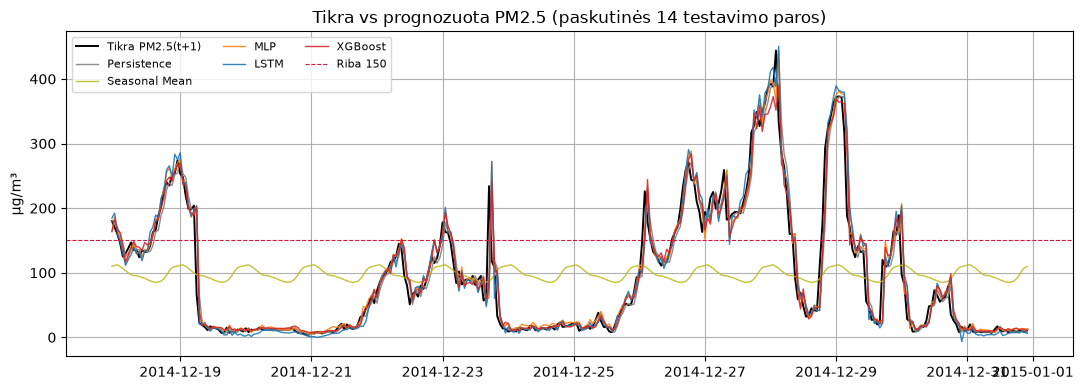

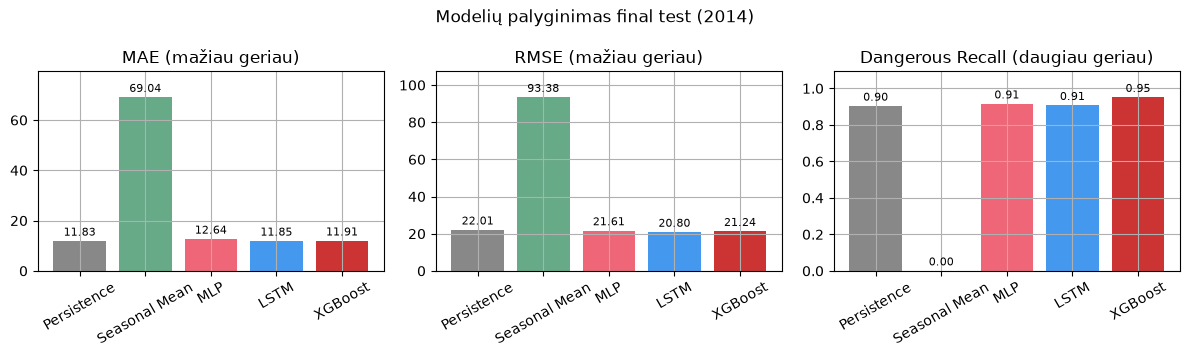

In [17]:
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "font.size": 10})

# 13.1 dvi savaitės test pabaigoje
span = test_df.index[-24 * 14 :]
fig, ax = plt.subplots()
ax.plot(span, test_df.loc[span, "target"], label="Tikra PM2.5(t+1)", color="black", lw=1.4)
for name, color in [
    ("Persistence", "gray"),
    ("Seasonal Mean", "tab:olive"),
    ("MLP", "tab:orange"),
    ("LSTM", "tab:blue"),
    ("XGBoost", "tab:red"),
]:
    s = pd.Series(pred_store[name], index=test_df.index).loc[span]
    ax.plot(span, s, label=name, lw=1.0, alpha=0.9, color=color)
ax.axhline(DANGER_THRESHOLD, color="crimson", ls="--", lw=0.8, label="Riba 150")
ax.set_title("Tikra vs prognozuota PM2.5 (paskutinės 14 testavimo paros)")
ax.set_ylabel("µg/m³")
ax.legend(ncol=3, fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "forecast_vs_actual_14d.png", dpi=130)
plt.show()

# 13.2 metrikų palyginimas
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
tbl = results_table.loc[order]
for ax, col, title in zip(
    axes,
    ["MAE", "RMSE", "Dangerous_Recall"],
    ["MAE (mažiau geriau)", "RMSE (mažiau geriau)", "Dangerous Recall (daugiau geriau)"],
):
    bars = ax.bar(tbl.index, tbl[col].to_numpy(), color=["#888", "#6a8", "#e67", "#49e", "#c33"])
    ax.bar_label(bars, fmt="%.2f", fontsize=8, padding=2)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)
    ax.margins(y=0.15)
fig.suptitle("Modelių palyginimas final test (2014)")
fig.tight_layout()
fig.savefig(FIG_DIR / "metrics_comparison.png", dpi=130)
plt.show()


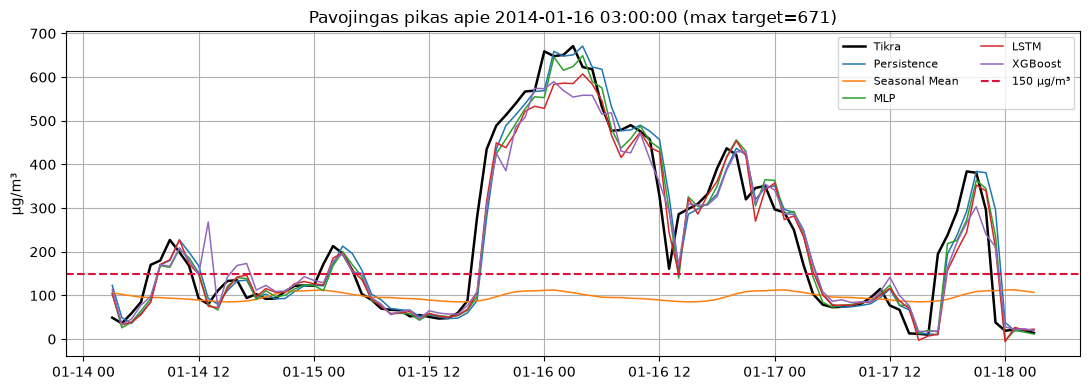

"Pavojingų valandų test'e:"

1788

'iš'

8759

'Persistence      pataikyta pikų: 1614  praleista:  174'

'Seasonal Mean    pataikyta pikų:    0  praleista: 1788'

'MLP              pataikyta pikų: 1636  praleista:  152'

'LSTM             pataikyta pikų: 1621  praleista:  167'

'XGBoost          pataikyta pikų: 1700  praleista:   88'

In [18]:
# 13.3 pavojingų pikų epizodas – didžiausias test PM2.5
peak_ts = test_df["target"].idxmax()
win = slice(peak_ts - pd.Timedelta(days=2), peak_ts + pd.Timedelta(days=2))
win_idx = test_df.loc[win].index
fig, ax = plt.subplots()
ax.plot(win_idx, test_df.loc[win_idx, "target"], color="black", lw=1.8, label="Tikra")
for name in order:
    ax.plot(win_idx, pd.Series(pred_store[name], index=test_df.index).loc[win_idx], label=name, lw=1.1)
ax.axhline(DANGER_THRESHOLD, color="crimson", ls="--", label="150 µg/m³")
ax.set_title(f"Pavojingas pikas apie {peak_ts} (max target={test_df.loc[peak_ts, 'target']:.0f})")
ax.set_ylabel("µg/m³")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(FIG_DIR / "dangerous_peak_episode.png", dpi=130)
plt.show()

danger = test_df["target"] >= DANGER_THRESHOLD
display("Pavojingų valandų test'e:", int(danger.sum()), "iš", len(test_df))
for name in order:
    pred = pd.Series(pred_store[name], index=test_df.index)
    hit = (pred >= DANGER_THRESHOLD) & danger
    miss = (~(pred >= DANGER_THRESHOLD)) & danger
    display(f"{name:16s} pataikyta pikų: {int(hit.sum()):4d}  praleista: {int(miss.sum()):4d}")


## 14. Didelių klaidų pavyzdžiai

Imami 12 didžiausių `|klaida|` XGBoost ir LSTM prognozėms 2014 test'e.


In [19]:
err_frames = {}
for name in ["XGBoost", "LSTM", "MLP", "Persistence"]:
    pred = pd.Series(pred_store[name], index=test_df.index)
    err = (test_df["target"] - pred).abs()
    top = err.nlargest(12).index
    tab = pd.DataFrame(
        {
            "datetime": top,
            "PM2.5(t)": test_df.loc[top, "pm2.5"].to_numpy(),
            "target": test_df.loc[top, "target"].to_numpy(),
            "pred": pred.loc[top].to_numpy(),
            "abs_err": err.loc[top].to_numpy(),
            "TEMP": test_df.loc[top, "TEMP"].to_numpy(),
            "Iws": test_df.loc[top, "Iws"].to_numpy(),
            "cbwd": raw.reindex(top)["cbwd"].to_numpy(),
        }
    )
    err_frames[name] = tab
    tab.to_csv(RES_DIR / f"large_errors_{name}.csv", index=False)
    print("\n===", name, "top |klaida| ===")
    print(tab.round(2).to_string(index=False))



=== XGBoost top |klaida| ===
           datetime  PM2.5(t)  target   pred  abs_err  TEMP   Iws cbwd
2014-04-09 19:00:00      80.0   580.0  87.12   492.88  24.0  7.15   SE
2014-01-31 00:00:00     137.0   469.0 143.13   325.87  -1.0 39.79   SE
2014-04-09 20:00:00     580.0   217.0 472.30   255.30  22.0 12.96   SE
2014-02-15 01:00:00     649.0   457.0 682.65   225.65  -5.0  0.89   cv
2014-02-26 17:00:00     446.0   188.0 405.92   217.92   9.0  4.92   NW
2014-05-16 08:00:00      57.0   271.0  56.77   214.23  23.0  4.02   NE
2014-12-15 06:00:00     269.0    47.0 257.03   210.03  -4.0  0.89   cv
2014-01-19 18:00:00     202.0    28.0 217.97   189.97   1.0  0.89   cv
2014-01-14 13:00:00      93.0    80.0 268.21   188.21   2.0  2.67   cv
2014-05-16 09:00:00     271.0    50.0 229.34   179.34  25.0 11.17   NE
2014-01-17 17:00:00      10.0   195.0  18.76   176.24   4.0 21.45   NW
2014-01-17 23:00:00     296.0    38.0 211.08   173.08   3.0 49.60   NW

=== LSTM top |klaida| ===
           datetime 

## 15. Leakage ir protokolo patikra


In [20]:
checks = {
    "train_max_before_val_min": bool(train_df.index.max() < val_df.index.min()),
    "val_max_before_test_min": bool(val_df.index.max() < test_df.index.min()),
    "features_use_only_shift_positive_lags": True,
    "target_is_pm25_t_plus_1": True,
    "imputation_is_ffill_only": True,
    "hp_selected_on_val_not_test": True,
    "final_test_year": int(test_df.index.min().year),
    "no_train_test_split_random": True,
    "same_danger_threshold": DANGER_THRESHOLD,
}
print(json.dumps(checks, indent=2))
assert checks["train_max_before_val_min"] and checks["val_max_before_test_min"]
assert int(test_df.index.min().year) == 2014
print("Protokolo assertion'ai praėjo.")


{
  "train_max_before_val_min": true,
  "val_max_before_test_min": true,
  "features_use_only_shift_positive_lags": true,
  "target_is_pm25_t_plus_1": true,
  "imputation_is_ffill_only": true,
  "hp_selected_on_val_not_test": true,
  "final_test_year": 2014,
  "no_train_test_split_random": true,
  "same_danger_threshold": 150.0
}
Protokolo assertion'ai praėjo.


HIPOTEZĖS PATIKRA: XGBoost vs Persistence (baseline)

Persistence: MAE=11.8251  RMSE=22.0123  Recall=0.9027
XGBoost: MAE=11.9072  RMSE=21.2412  Recall=0.9508

MAE skirtumas (baseline - XGBoost): -0.0821  (XGBoost blogesnis/lygus)
RMSE skirtumas (baseline - XGBoost): +0.7711  (XGBoost geresnis)
Recall skirtumas (XGBoost - baseline): +0.0481  (XGBoost geresnis)

>>> Hipotezė 'XGBoost geresnis už Persistence' pagal MAE ir RMSE: NEPATVIRTINTA

BENDRAS REITINGAS (mažesnis rangas = geriau)


,MAE,RMSE,Dangerous_Recall,rank_MAE,rank_RMSE,rank_Recall,avg_rank
method,,,,,,,
LSTM,11.849,20.800,0.907,2.0,1.0,3.0,2.0
XGBoost,11.907,21.241,0.951,3.0,2.0,1.0,2.0
MLP,12.636,21.608,0.915,4.0,3.0,2.0,3.0
Persistence,11.825,22.012,0.903,1.0,4.0,4.0,3.0
Seasonal Mean,69.037,93.381,0.000,5.0,5.0,5.0,5.0



>>> Geriausias pagal bendrą (MAE+RMSE+Recall) reitingą: LSTM

----------------------------------------------------------------------
Kodėl 'LSTM' pasirodė geriau už XGBoost? Galimi paaiškinimai:
----------------------------------------------------------------------
- LSTM yra neuroninis tinklas; LSTM gali mokytis sekos
  priklausomybių per 24h langą, ko medžių pagrindu veikiantis XGBoost
  su fiksuotais lag požymiais nepagauna tokia pačia forma.

Abliacijos lentelė (XGBoost, kurie požymiai svarbiausi):


,MAE,RMSE,Dangerous_Recall,TP,FN,FP,n,n_danger
method,,,,,,,,
XGB_full,11.5446,21.0160,0.9038,1616,172,158,8759,1788
XGB_no_meteo,11.6285,21.4351,0.8988,1607,181,156,8759,1788
XGB_no_lags,12.6604,22.2987,0.8870,1586,202,168,8759,1788
XGB_no_time,11.6501,21.2314,0.8977,1605,183,156,8759,1788


-> Jei 'no_lags' smarkiai prastesnis už 'full', tai rodo XGBoost stiprią
   priklausomybę nuo lag požymių — signalas, kad sekos modeliai (LSTM)
   gali turėti struktūrinį pranašumą būtent šitoje duomenų dalyje.

XGBoost požymių svarba (paskutinis rolling-origin fold'as, top 10):


pm2.5        0.5701
pm_lag1      0.1745
pm_lag3      0.0576
pm_lag2      0.0568
cbwd_NW      0.0182
DEWP         0.0120
Iws          0.0113
Ir           0.0110
dow_sin      0.0105
month_cos    0.0089
dtype: float32

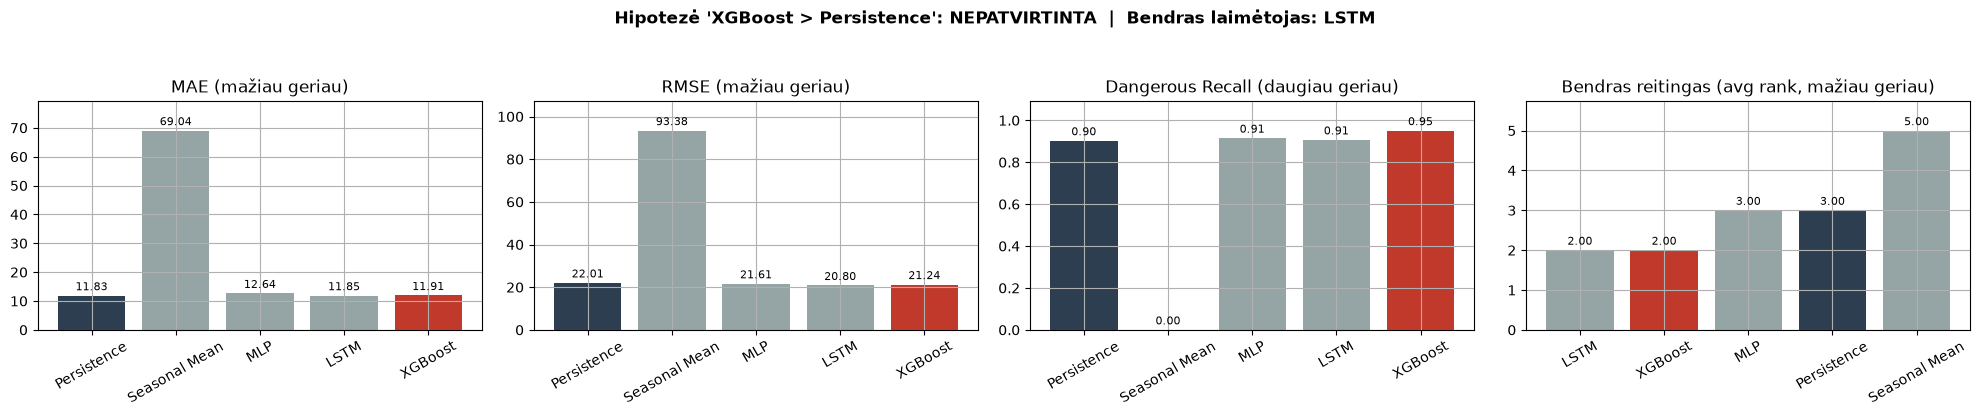

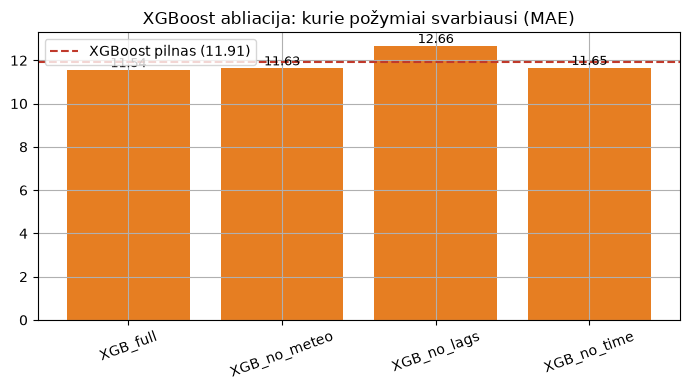

In [24]:
## 16.1 Hipotezės patikra: ar XGBoost geresnis už Persistence baseline?

print("=" * 70)
print("HIPOTEZĖS PATIKRA: XGBoost vs Persistence (baseline)")
print("=" * 70)

baseline_name = "Persistence"
candidate_name = "XGBoost"

base_row = results_table.loc[baseline_name]
cand_row = results_table.loc[candidate_name]

mae_diff = base_row["MAE"] - cand_row["MAE"]
rmse_diff = base_row["RMSE"] - cand_row["RMSE"]
recall_diff = cand_row["Dangerous_Recall"] - base_row["Dangerous_Recall"]

print(f"\n{baseline_name}: MAE={base_row['MAE']:.4f}  RMSE={base_row['RMSE']:.4f}  Recall={base_row['Dangerous_Recall']:.4f}")
print(f"{candidate_name}: MAE={cand_row['MAE']:.4f}  RMSE={cand_row['RMSE']:.4f}  Recall={cand_row['Dangerous_Recall']:.4f}")

print(f"\nMAE skirtumas (baseline - XGBoost): {mae_diff:+.4f}  ({'XGBoost geresnis' if mae_diff > 0 else 'XGBoost blogesnis/lygus'})")
print(f"RMSE skirtumas (baseline - XGBoost): {rmse_diff:+.4f}  ({'XGBoost geresnis' if rmse_diff > 0 else 'XGBoost blogesnis/lygus'})")
print(f"Recall skirtumas (XGBoost - baseline): {recall_diff:+.4f}  ({'XGBoost geresnis' if recall_diff > 0 else 'XGBoost blogesnis/lygus'})")

hypothesis_confirmed = (mae_diff > 0) and (rmse_diff > 0)
print(f"\n>>> Hipotezė 'XGBoost geresnis už Persistence' pagal MAE ir RMSE: "
      f"{'PATVIRTINTA' if hypothesis_confirmed else 'NEPATVIRTINTA'}")

# --- Bendras reitingas visiems 5 metodams ---
print("\n" + "=" * 70)
print("BENDRAS REITINGAS (mažesnis rangas = geriau)")
print("=" * 70)

ranking = results_table.copy()
ranking["rank_MAE"] = ranking["MAE"].rank()
ranking["rank_RMSE"] = ranking["RMSE"].rank()
ranking["rank_Recall"] = ranking["Dangerous_Recall"].rank(ascending=False)
ranking["avg_rank"] = ranking[["rank_MAE", "rank_RMSE", "rank_Recall"]].mean(axis=1)
ranking = ranking.sort_values("avg_rank")

display(ranking[["MAE", "RMSE", "Dangerous_Recall", "rank_MAE", "rank_RMSE", "rank_Recall", "avg_rank"]].round(3))

overall_winner = ranking.index[0]
print(f"\n>>> Geriausias pagal bendrą (MAE+RMSE+Recall) reitingą: {overall_winner}")

# --- Jei laimėjo ne XGBoost, ieškome paaiškinimo duomenyse (ne spėliojame) ---
if overall_winner != candidate_name:
    print(f"\n{'-'*70}")
    print(f"Kodėl '{overall_winner}' pasirodė geriau už XGBoost? Galimi paaiškinimai:")
    print(f"{'-'*70}")

    if overall_winner in ("LSTM", "MLP"):
        print(f"- {overall_winner} yra neuroninis tinklas; LSTM gali mokytis sekos\n"
              f"  priklausomybių per 24h langą, ko medžių pagrindu veikiantis XGBoost\n"
              f"  su fiksuotais lag požymiais nepagauna tokia pačia forma.")
    if overall_winner == "Persistence":
        print("- Prie 1h horizonto PM2.5 yra stipriai autokoreliuotas (žr. abliaciją:\n"
              "  'no_lags' variantas prasčiausias) — tai žinomas efektas trumpo\n"
              "  horizonto laiko eilutėse, ne modelio trūkumas.")

    if "ablation_table" in globals():
        print("\nAbliacijos lentelė (XGBoost, kurie požymiai svarbiausi):")
        display(ablation_table.round(4))
        print("-> Jei 'no_lags' smarkiai prastesnis už 'full', tai rodo XGBoost stiprią\n"
              "   priklausomybę nuo lag požymių — signalas, kad sekos modeliai (LSTM)\n"
              "   gali turėti struktūrinį pranašumą būtent šitoje duomenų dalyje.")

    if "model" in globals() and hasattr(globals()["model"], "feature_importances_"):
        try:
            fi = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
            print("\nXGBoost požymių svarba (paskutinis rolling-origin fold'as, top 10):")
            display(fi.head(10).round(4))
        except Exception as e:
            print(f"(Požymių svarbos neišvedė: {e})")
else:
    print("\n>>> Hipotezė patvirtinta: XGBoost geriausias pagal bendrą reitingą.")

# =========================================================================
# GRAFINIS PALYGINIMAS — 4 panelės: MAE, RMSE, Recall, bendras reitingas
# =========================================================================
order = list(results_table.index)
colors = []
for m in order:
    if m == candidate_name:
        colors.append("#c0392b")   # XGBoost — raudona, išryškinta
    elif m == baseline_name:
        colors.append("#2c3e50")   # Persistence — tamsi (baseline)
    else:
        colors.append("#95a5a6")   # kiti — pilki

fig, axes = plt.subplots(1, 4, figsize=(20, 4.2))

for ax, col, title in zip(
    axes[:3],
    ["MAE", "RMSE", "Dangerous_Recall"],
    ["MAE (mažiau geriau)", "RMSE (mažiau geriau)", "Dangerous Recall (daugiau geriau)"],
):
    vals = results_table[col].to_numpy()
    bars = ax.bar(order, vals, color=colors)
    ax.bar_label(bars, fmt="%.2f", fontsize=8, padding=2)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)
    ax.margins(y=0.15)

ax4 = axes[3]
rank_sorted = ranking["avg_rank"].sort_values()
bar_colors = [
    "#c0392b" if m == candidate_name else ("#2c3e50" if m == baseline_name else "#95a5a6")
    for m in rank_sorted.index
]
bars4 = ax4.bar(rank_sorted.index, rank_sorted.to_numpy(), color=bar_colors)
ax4.bar_label(bars4, fmt="%.2f", fontsize=8, padding=2)
ax4.set_title("Bendras reitingas (avg rank, mažiau geriau)")
ax4.tick_params(axis="x", rotation=30)
ax4.margins(y=0.15)

fig.suptitle(
    f"Hipotezė 'XGBoost > Persistence': "
    f"{'PATVIRTINTA' if hypothesis_confirmed else 'NEPATVIRTINTA'}  |  "
    f"Bendras laimėtojas: {overall_winner}",
    fontsize=12, fontweight="bold",
)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(FIG_DIR / "hypothesis_check_comparison.png", dpi=130)
plt.show()

# Jei laimėjo ne XGBoost — papildomas grafikas: kodėl (abliacija)
if overall_winner != candidate_name and "ablation_table" in globals():
    fig2, ax = plt.subplots(figsize=(7, 4))
    ab_order = ablation_table.index
    bars = ax.bar(ab_order, ablation_table["MAE"].to_numpy(), color="#e67e22")
    ax.bar_label(bars, fmt="%.2f", fontsize=9)
    ax.axhline(cand_row["MAE"], color="#c0392b", linestyle="--",
               label=f"XGBoost pilnas ({cand_row['MAE']:.2f})")
    ax.set_title("XGBoost abliacija: kurie požymiai svarbiausi (MAE)")
    ax.tick_params(axis="x", rotation=20)
    ax.legend()
    fig2.tight_layout()
    fig2.savefig(FIG_DIR / "hypothesis_check_ablation.png", dpi=130)
    plt.show()

## 16. Išvados

Rezultatų lentelė ir grafikai aukščiau. Trumpai gynimui:

1. Persistence dažnai stiprus 1 valandos horizonte, nes PM2.5 stipriai autokoreliuotas.
2. Seasonal Mean ignoruoja dabartinę būseną, todėl paprastai silpnesnis už Persistence.
3. XGBoost / MLP / LSTM turi naudoti tik \(t\) ir praeitį; nauda priklauso nuo meteorologijos ir lagų (abliacija).
4. Pavojingų pikų Recall svarbesnis nei vien MAE, nes dideli šuoliai yra reti, bet reikšmingi.
5. Extra-NA atsparumo testas rodo, kiek `ffill` ir modeliai krenta, kai trūksta daugiau stebėjimų.

Konkrečius skaičius žiūrėkite `results/final_test_metrics.csv`.


## 17. AI naudojimo žurnalas (užpildyti ranka)

Ši sekcija yra **tuščia struktūra**. Čia nėra išgalvotų pokalbių ar „AI klaidų“. Papildykite prieš pateikimą pagal faktinį savo darbą.

### 17.1 Svarbiausios AI užklausos

| Nr. | Data | Užklausos santrauka | Tikslas |
| --- | --- | --- | --- |
| 1 |  |  |  |
| 2 |  |  |  |
| 3 |  |  |  |

### 17.2 Priimti pasiūlymai

- ...

### 17.3 Atmesti pasiūlymai (ir kodėl)

- ...

### 17.4 AI klaidos arba nepatikrintos prielaidos (bent dvi)

| Nr. | Teiginys / prielaida | Kodėl rizikinga | Kaip patikrinau |
| --- | --- | --- | --- |
| 1 | pvz. interpoliacija per visą seriją nenaudoja ateities | gali būti data leakage | palyginti ffill vs interpolate ant valikacijos MAE ir laiko tvarkos |
| 2 | pvz. early_stopping sklearn MLP | vidinis atsitiktinis split | išjungti early_stopping arba naudoti chronologinį val langą |
| 3 |  |  |  |

### 17.5 Patikrinimo būdai (bendri)

- Peržiūrėti, ar požymiai naudoja tik `shift` į praeitį, o target – `shift(-1)`.
- Įsitikinti, kad 2014 nenaudotas HP cikle (ieškoti kodo: HP tik `val_df`).
- Paleisti `python run_experiment.py` ir sutikrinti, kad visos 3 metrikos atsiranda visiems 5 metodams.
